<a href="https://colab.research.google.com/github/JulTob/Data/blob/main/P4_Analisis-Wind.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 4

## ⚠️ IMPORTANTE ⚠️
- En el menú superior seleccionar: `Runtime` ⇒ `Change Runtime Type` ⇲ `Runtime Type`⇒ `R`


Confirmamos que funcione R

In [1]:
R.version.string

[1] "R version 4.5.1 (2025-06-13)"

Para asegurar reproducibilidad se ha hosteado el archivo csv en GitHub.

In [2]:
install.packages("readr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
library(readr)
url <- "https://raw.githubusercontent.com/JulTob/Data/main/CSVs/temperatura.csv"
df <- read_delim(url, delim = ";")
head(df)

Rows: 23 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ";"
chr (2): City, Area
dbl (4): Annual, Amplitude, Latitude, Longitude

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


City,Annual,Amplitude,Latitude,Longitude,Area
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Amsterdam,9.9,14.6,52.2,4.5,West
Athens,17.8,18.3,37.6,23.5,South
Berlin,9.1,18.5,52.3,13.2,West
Brussels,10.3,14.4,50.5,4.2,West
Budapest,10.9,23.1,47.3,19.0,East
Copenhagen,7.8,17.5,55.4,12.3,North


# Ejercicio 1:

In [5]:
install.packages("nasaweather")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [6]:
library(nasaweather)
data(storms)
print(storms)

# A tibble: 2,747 × 12
   name     year month   day  hour   lat  long pressure  wind type       seasday
   <chr>   <int> <int> <int> <int> <dbl> <dbl>    <int> <int> <chr>        <int>
 1 Allison  1995     6     3     0  17.4 -84.3     1005    30 Tropical …       3
 2 Allison  1995     6     3     6  18.3 -84.9     1004    30 Tropical …       3
 3 Allison  1995     6     3    12  19.3 -85.7     1003    35 Tropical …       3
 4 Allison  1995     6     3    18  20.6 -85.8     1001    40 Tropical …       3
 5 Allison  1995     6     4     0  22   -86        997    50 Tropical …       4
 6 Allison  1995     6     4     6  23.3 -86.3      995    60 Tropical …       4
 7 Allison  1995     6     4    12  24.7 -86.2      987    65 Hurricane        4
 8 Allison  1995     6     4    18  26.2 -86.2      988    65 Hurricane        4
 9 Allison  1995     6     5     0  27.6 -86.1      988    65 Hurricane        5
10 Allison  1995     6     5     6  28.5 -85.6      990    60 Tropical …       5
# ℹ 2

In [7]:
# 1 mbar = 100 Pascales [Pa] = [N]/[m2]
# 1 nudo = 0.514444 metros por segundo (m/s)

storms_si <- storms
    #-- Storms con unidades del SI

storms_si$pressure_pa <- storms_si$pressure * 100
storms_si$wind_ms <- storms_si$wind * 0.514444

# Display
head(storms_si)

name,year,month,day,hour,lat,long,pressure,wind,type,seasday,category,pressure_pa,wind_ms
<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Allison,1995,6,3,0,17.4,-84.3,1005,30,Tropical Depression,3,-1,100500,15.43332
Allison,1995,6,3,6,18.3,-84.9,1004,30,Tropical Depression,3,-1,100400,15.43332
Allison,1995,6,3,12,19.3,-85.7,1003,35,Tropical Storm,3,0,100300,18.00554
Allison,1995,6,3,18,20.6,-85.8,1001,40,Tropical Storm,3,0,100100,20.57776
Allison,1995,6,4,0,22.0,-86.0,997,50,Tropical Storm,4,0,99700,25.72220
Allison,1995,6,4,6,23.3,-86.3,995,60,Tropical Storm,4,0,99500,30.86664


### Media y Mediana

In [8]:
# Medidas centrales de tendencia
mean_wind_ms <- mean(storms_si$wind_ms)
median_wind_ms <- median(storms_si$wind_ms)

cat("Mean of wind_ms:", mean_wind_ms, "\n")
cat("Median of wind_ms:", median_wind_ms, "\n")


Mean of wind_ms: 28.13149 
Median of wind_ms: 25.7222 


# Moda

Lo más natural es dividir el rango entre el máximo y mínimo valor, dividirlo en $Log(N)$ medidas (siendo N el Nº total de medidas). Se puede realizar el histograma de esta tabla, pero para obtener la moda swolo necesitamos el máximo.

Un detalle a considerar es el tamaño de la base del logaritmo. Como norma general, base 2 tiene ciertas propiedades de interés (entropia, digitalización...) pero sobretodo tiene la bondad de referirse a 'divisiones por la mitad'. Además de ser la representación más granular.

In [9]:
# Calculate the range of wind_ms
min_wind_ms <- min(storms_si$wind_ms, na.rm = TRUE)
max_wind_ms <- max(storms_si$wind_ms, na.rm = TRUE)

N <- length(storms_si$wind_ms)
num_divisions <- ceiling(log2(N))
    #-- Base 2 es la más detallada

bins <- seq(
    min_wind_ms,
    max_wind_ms,
    length.out = num_divisions)

wind_ms_binned <- cut(
    storms_si$wind_ms,
    breaks = bins,
    include.lowest = TRUE)

# Tabla de frecuencia
wind_ms_freq <- table(wind_ms_binned)

# La agrupación modal
mode_bin_index <- which.max(wind_ms_freq)
mode_bin <- names(mode_bin_index)


cat("Nº de Divisiones:", num_divisions, "\n")
head(wind_ms_freq)
cat("Tramo de Moda de wind_ms:", mode_bin, "\n")


Nº de Divisiones: 12 


wind_ms_binned
[7.72,14.3] (14.3,20.8] (20.8,27.4] (27.4,33.9] (33.9,40.5]   (40.5,47] 
        293         791         436         479         255         231 

Tramo de Moda de wind_ms: (14.3,20.8] 


Ahora podemos calcular la marca del intervalo (bin).

In [10]:
min_bin <- bins[mode_bin_index]
max_bin <- bins[mode_bin_index + 1]

cat("Min de la bin modal:", min_bin, "\n")
cat("Max de la bin modal:", max_bin, "\n")

mode_wind_ms = (min_bin + max_bin)/2
cat("Valor de marca de la moda:", mode_wind_ms)

Min de la bin modal: 14.26413 
Max de la bin modal: 20.8116 
Valor de marca de la moda: 17.53786

Podemos aprovechar la tabla para representar los datos.

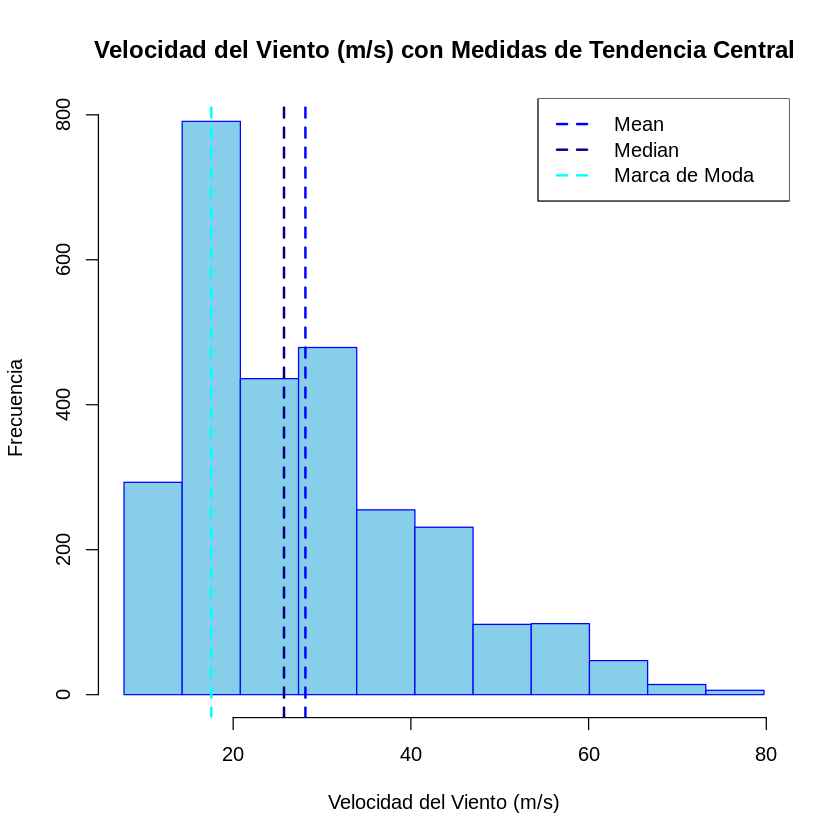

In [11]:
hist(storms_si$wind_ms, breaks = bins, main = "Velocidad del Viento (m/s) con Medidas de Tendencia Central", xlab = "Velocidad del Viento (m/s)", ylab = "Frecuencia", col = "skyblue", border = "blue")

# Add vertical lines for mean, median, and mean within the modal bin
abline(v = mean_wind_ms, col = "blue", lty = 2, lwd = 2)
abline(v = median_wind_ms, col = "navy", lty = 2, lwd = 2)
abline(v = mode_wind_ms, col = "cyan", lty = 2, lwd = 2)

# Add a legend
legend("topright", legend = c("Mean", "Median", "Marca de Moda"), col = c("blue", "navy", "cyan"), lty = 2, lwd = 2)

Vemos gracias al Log2 que se trata de una distribución más o menos Parettoide.

Yo particularmente entiendo mejor el uso de kmh que ms. Podemos convertir fácilmente estas medidas de tendencia para entender mejor estas medidas de tendencia.

In [12]:
# Conversion factor from m/s to km/h
ms_to_kmh <- 3.6

# Convert mean, median, and mean in modal bin to km/h
mean_wind_kmh <- mean_wind_ms * ms_to_kmh
median_wind_kmh <- median_wind_ms * ms_to_kmh
mode_wind_kmh <- mode_wind_ms * ms_to_kmh

# Display the results
cat("Mean of wind speed (km/h):", mean_wind_kmh, "\n")
cat("Median of wind speed (km/h):", median_wind_kmh, "\n")
cat("Mean in modal bin of wind speed (km/h):", mode_wind_kmh, "\n")

Mean of wind speed (km/h): 101.2734 
Median of wind speed (km/h): 92.59992 
Mean in modal bin of wind speed (km/h): 63.13631 


Esto permite entender que de media el viento en una tormenta alcanza los 100 kilometros por hora, pero la observación más medida será de poco más de 60 kilometros por hora.

Esto significa, por ejemplo, que el impacto por un objeto llevado por el viento es comparable a que se lancen desde un coche en carretera comarcal para el grueso de objetos, pero la mayoría sería equivalentes a que lo lance un coche en autovía. El efecto a la larga seria que cada objeto ha sido lanzado a una velocidad de autovia de 100 kmh.

 <!--< Se nota que trabajo en seguros? >-->

### Calcula el primer y tercer cuartil e interpreta los resultados.

In [13]:
# Calculate the first and third quartiles of wind_ms
quartiles_wind_ms <- quantile(storms_si$wind_ms, probs = c(0.25, 0.75), na.rm = TRUE)

# Extract the first and third quartiles
q1_wind_ms <- quartiles_wind_ms[1]
q3_wind_ms <- quartiles_wind_ms[2]

cat("Primer Quartil (Q1) de wind_ms:", q1_wind_ms, "\n")
cat("Tercer Quartil (Q3) de wind_ms:", q3_wind_ms, "\n")

Primer Quartil (Q1) de wind_ms: 18.00554 
Tercer Quartil (Q3) de wind_ms: 36.01108 


### Calcula P5 y P80 en interpreta los resultados

In [14]:
# Calculate the 5th and 80th percentiles of wind_ms
percentiles_wind_ms <- quantile(storms_si$wind_ms, probs = c(0.05, 0.80), na.rm = TRUE)

# Extract the 5th and 80th percentiles
p5_wind_ms <- percentiles_wind_ms[1]
p80_wind_ms <- percentiles_wind_ms[2]

cat("5º Percentil (P5) de wind_ms:", p5_wind_ms, "\n")
cat("80º Percentil (P80) de wind_ms:", p80_wind_ms, "\n")

5th Percentile (P5) of wind_ms: 12.8611 
80th Percentile (P80) of wind_ms: 38.5833 


### d) Calcula el rango y el rango intercuartílico.

In [16]:
# Rango de wind_ms
range_wind_ms <- max(storms_si$wind_ms, na.rm = TRUE) - min(storms_si$wind_ms, na.rm = TRUE)

# Rango Interquartil(IQR) de wind_ms
# Ya tenemos Q1 y Q3
iqr_wind_ms <- q3_wind_ms - q1_wind_ms

cat("Rango de wind_ms:", range_wind_ms, "\n")
cat("Rango Interquartil (IQR) de wind_ms:", iqr_wind_ms, "\n")

Rango de wind_ms: 72.02216 
Rango Interquartil (IQR) de wind_ms: 18.00554 


### Calcula la desviación media y la desviación media respecto de la mediana.

In [17]:
# Calculate the Mean Absolute Deviation (deviation from the mean)
mad_mean_wind_ms <- mean(abs(storms_si$wind_ms - mean_wind_ms), na.rm = TRUE)

# Calculate the Mean Absolute Deviation from the Median
mad_median_wind_ms <- mean(abs(storms_si$wind_ms - median_wind_ms), na.rm = TRUE)

cat("Mean Absolute Deviation (from Mean) of wind_ms:", mad_mean_wind_ms, "\n")
cat("Mean Absolute Deviation (from Median) of wind_ms:", mad_median_wind_ms, "\n")

Mean Absolute Deviation (from Mean) of wind_ms: 10.76965 
Mean Absolute Deviation (from Median) of wind_ms: 10.51267 


### Calcula la varianza y desviación típica

In [18]:
# Calculate the variance of wind_ms
variance_wind_ms <- var(storms_si$wind_ms, na.rm = TRUE)

# Calculate the standard deviation of wind_ms
sd_wind_ms <- sd(storms_si$wind_ms, na.rm = TRUE)

cat("Variance of wind_ms:", variance_wind_ms, "\n")
cat("Standard Deviation of wind_ms:", sd_wind_ms, "\n")

Variance of wind_ms: 176.8262 
Standard Deviation of wind_ms: 13.2976 


### Calcula el coeficiente de variación de Pearson e Intercuartílico.
¿Los datos están muy
dispersos?

In [19]:
# Calculate Pearson's Coefficient of Variation
# CV_Pearson = (Standard Deviation / Mean) * 100
cv_pearson <- (sd_wind_ms / mean_wind_ms) * 100

# Calculate the Interquartile Coefficient of Variation
# CV_IQR = ((Q3 - Q1) / (Q3 + Q1)) * 100
cv_iqr <- ((q3_wind_ms - q1_wind_ms) / (q3_wind_ms + q1_wind_ms)) * 100

cat("Pearson's Coefficient of Variation:", cv_pearson, "%\n")
cat("Interquartile Coefficient of Variation:", cv_iqr, "%\n")

Pearson's Coefficient of Variation: 47.26945 %
Interquartile Coefficient of Variation: 33.33333 %


### h) Valora la forma de la distribución de esta variable (asimetría y curtosis).

In [20]:
# Calculate skewness manually
n <- length(storms_si$wind_ms)
mean_wind_ms <- mean(storms_si$wind_ms, na.rm = TRUE)
sd_wind_ms <- sd(storms_si$wind_ms, na.rm = TRUE)

skewness_manual <- (1/n) * sum(((storms_si$wind_ms - mean_wind_ms) / sd_wind_ms)^3, na.rm = TRUE)

cat("Manual Skewness of wind_ms:", skewness_manual, "\n")

Manual Skewness of wind_ms: 0.8981482 


In [21]:
# Calculate kurtosis (excess kurtosis) manually
n <- length(storms_si$wind_ms)
mean_wind_ms <- mean(storms_si$wind_ms, na.rm = TRUE)
sd_wind_ms <- sd(storms_si$wind_ms, na.rm = TRUE)

kurtosis_manual <- ((1/n) * sum(((storms_si$wind_ms - mean_wind_ms) / sd_wind_ms)^4, na.rm = TRUE)) - 3

cat("Manual Kurtosis (Excess) of wind_ms:", kurtosis_manual, "\n")

Manual Kurtosis (Excess) of wind_ms: 0.3246446 


### Realiza un histograma y el gráfico de cajas de la variable wind e interpreta los gráficos.

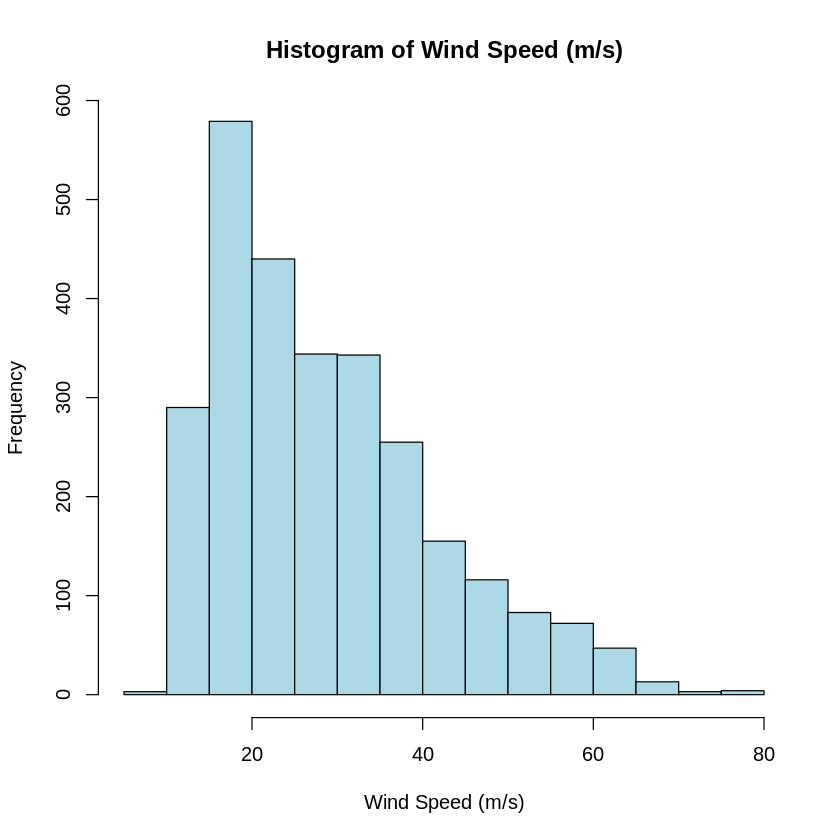

In [24]:
# Create a histogram of the 'wind' variable
hist(storms_si$wind_ms, main = "Histogram of Wind Speed (m/s)", xlab = "Wind Speed (m/s)", ylab = "Frequency", col = "lightblue", border = "black")

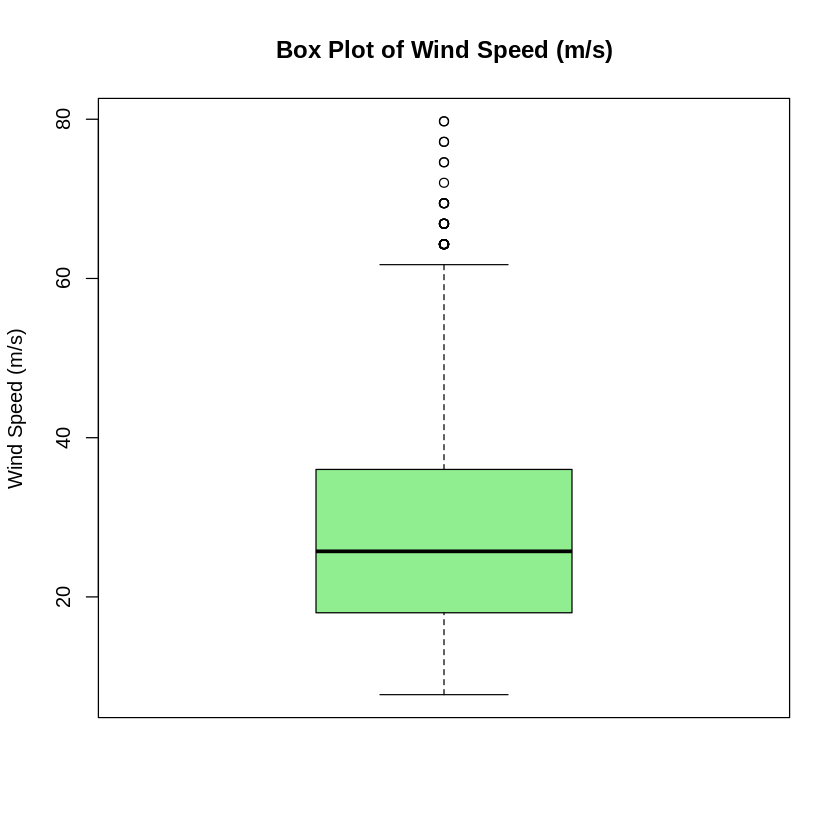

In [25]:
# Create a box plot of the 'wind' variable
boxplot(storms_si$wind_ms, main = "Box Plot of Wind Speed (m/s)", ylab = "Wind Speed (m/s)", col = "lightgreen", border = "black")